# E-COMMERCE BUSINESS ANALYSIS

# 1. Project Introduction

## Business Context

The goal of this project is to analyze an e-commerce dataset in order to better understand customer behavior, marketing performance, 
product performance, and sales activity.

The analysis focuses on identifying:
- what generates the most revenue,
- which customer acquisition channels perform best,
- where users may leave before purchasing,
- and what business opportunities or problems can be detected from the data.

This project also aims to explore:
- customer conversion behavior,
- loyalty and repeat purchasing,
- marketing efficiency,
- and the impact of different experiment groups on user behavior.


---

# 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---

# 3. Load Datasets

In [2]:
campaigns_df = pd.read_csv(r"C:\Users\Tooba Shaukat\OneDrive\ecommerce\campaigns.csv", index_col=0)

In [3]:
campaigns_df.head()

,channel,objective,start_date,end_date,target_segment,expected_uplift
campaign_id,,,,,,
1,Paid Search,Cross-sell,2021-10-25,2021-11-26,Deal Seekers,0.022
2,Email,Retention,2021-10-24,2021-12-24,Deal Seekers,0.116
3,Email,Reactivation,2023-10-08,2023-11-30,Churn Risk,0.100
4,Display,Reactivation,2022-07-25,2022-10-07,Deal Seekers,0.111
5,Social,Acquisition,2022-07-09,2022-09-29,New Customers,0.144


In [4]:
campaigns_df.shape

(50, 6)

In [5]:
campaigns_df.columns

Index(['channel', 'objective', 'start_date', 'end_date', 'target_segment',
       'expected_uplift'],
      dtype='object')

In [6]:
customers_df = pd.read_csv(r"C:\Users\Tooba Shaukat\OneDrive\ecommerce\customers.csv", index_col=0)

In [7]:
customers_df.head()

,signup_date,country,age,gender,loyalty_tier,acquisition_channel
customer_id,,,,,,
1,2021-04-08,BR,48,Male,Bronze,Referral
2,2023-04-28,IN,36,Female,Silver,Organic
3,2022-12-18,UK,35,Female,Silver,Organic
4,2022-04-26,US,45,Male,Silver,Paid Search
5,2022-04-20,IN,53,Male,Silver,Organic


In [8]:
customers_df.shape

(100000, 6)

In [9]:
customers_df.columns

Index(['signup_date', 'country', 'age', 'gender', 'loyalty_tier',
       'acquisition_channel'],
      dtype='object')

In [10]:
events_df = pd.read_csv(r"C:\Users\Tooba Shaukat\OneDrive\ecommerce\events.csv", index_col=0)

In [11]:
events_df.head()

,timestamp,customer_id,session_id,event_type,product_id,device_type,traffic_source,campaign_id,page_category,session_duration_sec,experiment_group
event_id,,,,,,,,,,,
1,2021-01-14 13:35:43,43812,535101,view,1004.0,desktop,Email,43,PLP,115.1,Control
2,2021-12-03 21:36:50,71340,96426,add_to_cart,986.0,desktop,Email,10,PDP,32.4,Variant_A
3,2021-12-27 08:25:15,59540,220126,purchase,1630.0,mobile,Organic,0,PDP,190.7,Variant_A
4,2022-01-22 15:06:54,3601,484555,add_to_cart,1532.0,desktop,Paid Search,30,Checkout,134.8,Variant_B
5,2021-05-10 12:03:09,92735,60646,bounce,NaN,desktop,Email,26,PLP,53.1,Variant_A


In [12]:
events_df.shape

(2000000, 11)

In [13]:
events_df.columns

Index(['timestamp', 'customer_id', 'session_id', 'event_type', 'product_id',
       'device_type', 'traffic_source', 'campaign_id', 'page_category',
       'session_duration_sec', 'experiment_group'],
      dtype='object')

In [14]:
products_df = pd.read_csv(r"C:\Users\Tooba Shaukat\OneDrive\ecommerce\products.csv", index_col=0)

In [15]:
products_df.head()

,category,brand,base_price,launch_date,is_premium
product_id,,,,,
1,Grocery,Brand_58,14.19,2021-08-02,0
2,Fashion,Brand_1,25.80,2021-09-14,0
3,Electronics,Brand_70,165.46,2021-01-18,1
4,Fashion,Brand_56,75.45,2023-03-03,1
5,Sports,Brand_1,72.50,2022-04-19,1


In [16]:
products_df.shape

(2000, 5)

In [17]:
products_df.columns

Index(['category', 'brand', 'base_price', 'launch_date', 'is_premium'], dtype='object')

In [18]:
transactions_df = pd.read_csv(r"C:\Users\Tooba Shaukat\OneDrive\ecommerce\transactions.csv", index_col=0)

In [19]:
transactions_df.head()

,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
transaction_id,,,,,,,,
1,2021-12-27 08:25:15,59540,1630.0,3,0.00,43.74,0,0
2,2023-06-06 21:14:26,54871,1901.0,3,0.00,174.78,21,0
3,2023-08-31 05:29:54,51818,1884.0,1,0.00,40.61,37,0
4,2022-06-26 20:33:46,18164,1114.0,2,0.15,68.76,13,0
5,2023-07-26 18:12:35,86915,408.0,1,0.00,14.64,4,0


In [20]:
transactions_df.shape

(103127, 8)

In [21]:
transactions_df.columns

Index(['timestamp', 'customer_id', 'product_id', 'quantity',
       'discount_applied', 'gross_revenue', 'campaign_id', 'refund_flag'],
      dtype='object')

Dataset	             Rows	               Role

campaigns	         50	                   Marketing strategy
customers	         100,000	           Customer profile
events	             2,000,000	           Website behavior
products	         2,000	               Product catalog
transactions	     103,127	           Revenue / purchases

---


# 4. Dataset Relationships & Data Model

The analysis is based on five interconnected datasets representing different aspects of an e-commerce business ecosystem:

## 1. campaigns_df
Contains marketing campaign information:
- campaign channels,
- objectives,
- target segments,
- expected uplift.

Primary key:
- `campaign_id`

---

## 2. customers_df
Contains customer demographic and acquisition information:
- country,
- age,
- gender,
- loyalty tier,
- acquisition channel.

Primary key:
- `customer_id`

---

## 3. events_df
Tracks customer behavioral interactions on the platform:
- views,
- clicks,
- add-to-cart events,
- purchases,
- bounce events.

This table connects:
- customers,
- products,
- and campaigns.

Foreign keys:
- `customer_id`
- `product_id`
- `campaign_id`

---

## 4. products_df
Contains product catalog information:
- category,
- brand,
- base price,
- premium status.

Primary key:
- `product_id`

---

## 5. transactions_df
Contains completed transaction information:
- purchased products,
- revenue,
- discounts,
- refunds,
- campaign attribution.

Foreign keys:
- `customer_id`
- `product_id`
- `campaign_id`

---

## Dataset Relationships

The datasets are connected through shared identifiers:

- `customer_id`
  links customers with events and transactions.

- `product_id`
  links products with events and transactions.

- `campaign_id`
  links marketing campaigns with events and transactions.

These relationships make it possible to analyze:
- customer behavior,
- marketing performance,
- product performance,
- conversion funnels,
- and revenue generation across the e-commerce ecosystem.

---


# 5. Data Quality Checks

In [22]:
for name, df in {
    "campaigns": campaigns_df,
    "customers": customers_df,
    "events": events_df,
    "products": products_df,
    "transactions": transactions_df
}.items():
    print("\n", name.upper())
    print("Shape:", df.shape)
    print("Duplicates:", df.duplicated().sum())
    print("Missing values:")
    print(df.isna().sum())


 CAMPAIGNS
Shape: (50, 6)
Duplicates: 0
Missing values:
channel            0
objective          0
start_date         0
end_date           0
target_segment     0
expected_uplift    0
dtype: int64

 CUSTOMERS
Shape: (100000, 6)
Duplicates: 1313
Missing values:
signup_date            0
country                0
age                    0
gender                 0
loyalty_tier           0
acquisition_channel    0
dtype: int64

 EVENTS
Shape: (2000000, 11)
Duplicates: 0
Missing values:
timestamp                    0
customer_id                  0
session_id                   0
event_type                   0
product_id              200371
device_type              40300
traffic_source               0
campaign_id                  0
page_category                0
session_duration_sec         0
experiment_group             0
dtype: int64

 PRODUCTS
Shape: (2000, 5)
Duplicates: 0
Missing values:
category       0
brand          0
base_price     0
launch_date    0
is_premium     0
dtype: int64

 TRANS

## Investigating duplicate values in customers_df

In [23]:
customers_df[customers_df.duplicated()].head()

,signup_date,country,age,gender,loyalty_tier,acquisition_channel
customer_id,,,,,,
615,2023-01-22,US,32,Female,Bronze,Referral
6360,2022-07-10,IN,35,Male,Bronze,Email
6498,2023-08-21,US,37,Male,Bronze,Paid Search
7048,2022-02-22,US,18,Male,Bronze,Referral
7409,2022-08-13,US,52,Female,Bronze,Paid Search


In [24]:
duplicate_rows = customers_df[
    customers_df.duplicated(keep=False)
]

duplicate_rows.sort_index().head(10)

,signup_date,country,age,gender,loyalty_tier,acquisition_channel
customer_id,,,,,,
8,2023-02-03,US,36,Male,Bronze,Organic
44,2022-01-24,US,29,Female,Bronze,Organic
57,2022-08-22,UK,25,Female,Bronze,Paid Search
61,2023-10-08,US,30,Male,Bronze,Paid Search
75,2023-01-22,US,32,Female,Bronze,Referral
105,2023-05-23,US,41,Male,Silver,Social
196,2021-04-06,US,44,Female,Bronze,Organic
213,2023-05-14,US,36,Male,Bronze,Organic
241,2021-06-03,IN,37,Female,Bronze,Social


In [25]:
customers_df.index.duplicated().sum()

0

### Duplicate Analysis

Initial duplicate detection suggested repeated rows in the customer dataset.

However, further investigation showed that these rows correspond to different customer IDs sharing similar demographic profiles rather than true duplicate customers.

Therefore, no rows were removed from the customer dataset.

## Investigating missing values in events_df

In [26]:
missing_product_by_event = (
    events_df
    .groupby("event_type")["product_id"]
    .apply(lambda x: x.isna().mean() * 100)
    .sort_values(ascending=False)
)

missing_product_by_event

event_type
bounce         100.000000
purchase        10.132167
add_to_cart      0.000000
click            0.000000
view             0.000000
Name: product_id, dtype: float64

## Missing Product ID Analysis

- Bounce events show 100% missing product identifiers, which is expected because users may leave the website before interacting with a specific product.

- Product-related interactions such as views, clicks, and add-to-cart events have complete product tracking, indicating strong tracking consistency for browsing behavior.

- However, approximately 10% of purchase events are missing product identifiers. This may indicate incomplete transaction attribution or tracking inconsistencies during the purchase process.

This issue could reduce the accuracy of:
- product performance analysis,
- campaign attribution,
- and revenue reporting.

## Filling missing values in device_type

In [27]:
events_df["device_type"].value_counts(dropna=False)

device_type
mobile     1176146
desktop     685433
tablet       98121
NaN          40300
Name: count, dtype: int64

In [28]:
events_df["device_type"] = events_df["device_type"].fillna("Unknown")

In [29]:
events_df["device_type"].value_counts(dropna=False)

device_type
mobile     1176146
desktop     685433
tablet       98121
Unknown      40300
Name: count, dtype: int64

## Device Distribution Analysis

Mobile traffic represents the majority of website interactions, suggesting that mobile experience optimization is likely critical for business performance.

Desktop traffic remains significant, while tablet usage is comparatively low.

A small proportion of sessions have unknown device information, which may result from incomplete tracking or unidentified traffic sources.

## Investigating missing values in transactions_df

In [30]:
transactions_df[
    transactions_df["product_id"].isna()
].head()

,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
transaction_id,,,,,,,,
16,2021-02-13 07:36:17,33154,NaN,1,0.05,NaN,29,0
21,2023-03-29 19:49:38,52652,NaN,1,0.00,NaN,40,0
22,2021-08-01 15:47:25,30425,NaN,1,0.15,NaN,49,0
56,2023-06-13 04:11:11,1280,NaN,3,0.15,NaN,0,0
58,2022-07-23 20:38:49,32032,NaN,1,0.05,NaN,13,0


In [31]:
transactions_df[
    transactions_df["gross_revenue"].isna()
].head()

,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag
transaction_id,,,,,,,,
16,2021-02-13 07:36:17,33154,NaN,1,0.05,NaN,29,0
21,2023-03-29 19:49:38,52652,NaN,1,0.00,NaN,40,0
22,2021-08-01 15:47:25,30425,NaN,1,0.15,NaN,49,0
56,2023-06-13 04:11:11,1280,NaN,3,0.15,NaN,0,0
58,2022-07-23 20:38:49,32032,NaN,1,0.05,NaN,13,0


In [32]:
transactions_df[
    transactions_df["product_id"].isna() &
    transactions_df["gross_revenue"].isna()
].shape

(10449, 8)

 Analysis: All rows with missing product_id
also have missing gross_revenue

In [33]:
missing_transaction_rate = (
    transactions_df["gross_revenue"].isna().mean() * 100
)

missing_transaction_rate

10.132167133728316

In [34]:
transactions_df[
    transactions_df["gross_revenue"].isna()
]["campaign_id"].value_counts().head(10)

campaign_id
0     2166
44     252
18     242
7      239
49     230
17     230
29     229
25     222
5      219
40     213
Name: count, dtype: int64

## Transaction Data Quality & Revenue Leakage

Approximately 10.13% of transaction records contain missing product and revenue information.

The issue is not isolated to a single campaign and appears across multiple marketing campaigns.

Campaign ID 0 accounts for the highest number of incomplete transactions, which may indicate weaker attribution tracking for unattributed or direct traffic sources.

Potential business impacts include:
- inaccurate campaign ROI measurement,
- underestimation of revenue,
- reduced product-level visibility,
- and weaker conversion analysis.

This may represent a form of operational or analytical revenue leakage.

## CONVERT DATES

In [35]:
campaigns_df["start_date"] = pd.to_datetime(campaigns_df["start_date"])
campaigns_df["end_date"] = pd.to_datetime(campaigns_df["end_date"])
customers_df["signup_date"] = pd.to_datetime(customers_df["signup_date"])
events_df["timestamp"] = pd.to_datetime(events_df["timestamp"])
products_df["launch_date"] = pd.to_datetime(products_df["launch_date"])
transactions_df["timestamp"] = pd.to_datetime(transactions_df["timestamp"])

## TRAFFIC SOURCE CLEANING

During the analysis of traffic sources, some categories appeared duplicated because of inconsistent capitalization.

For example:
- "EMAIL" and "Email"
- "SOCIAL" and "Social"
- "ORGANIC" and "Organic"

This type of inconsistency can affect grouping and aggregation results during analysis.

To ensure accurate analysis, traffic source values were standardized using title formatting.

In [36]:
events_df["traffic_source"].value_counts()

traffic_source
Organic        776758
Paid Search    387657
Social         291194
Email          290651
Direct         193870
ORGANIC         23731
PAID SEARCH     12181
SOCIAL           9077
EMAIL            8989
DIRECT           5892
Name: count, dtype: int64

In [37]:
events_df["traffic_source"] = (
    events_df["traffic_source"]
    .str.title()
)

In [38]:
events_df["traffic_source"].value_counts()

traffic_source
Organic        800489
Paid Search    399838
Social         300271
Email          299640
Direct         199762
Name: count, dtype: int64

---


# 7. Data Preparation for Analysis
### Creating Clean Transactions Dataset

Removing incomplete transactions.

The transactions dataset contains incomplete rows with missing:
- product identifiers,
- and revenue values.

Since these transactions cannot be used reliably for revenue analysis, they are excluded from KPI and business analysis calculations.

In [39]:
# creating clean transactions dataset
transactions_clean = transactions_df.dropna(
    subset=["gross_revenue", "product_id"]
)

In [40]:
# verifying missing values removed
transactions_clean.isna().sum()

timestamp           0
customer_id         0
product_id          0
quantity            0
discount_applied    0
gross_revenue       0
campaign_id         0
refund_flag         0
dtype: int64

The cleaned transaction dataset will be used for revenue, customer, and product performance analysis.

## Creating Merged Analytical Tables

To perform deeper business analysis, the cleaned transaction dataset is merged with:
- the product dataset,
- and the customer dataset.

This allows analysis of:
- product performance,
- customer behavior,
- acquisition channels,
- loyalty segments,
- and revenue generation.

In [41]:
#Merge Transactions + Products
transactions_products = transactions_clean.merge(
    products_df,
    on="product_id",
    how="left"
)

In [42]:
transactions_products.head()

,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag,category,brand,base_price,launch_date,is_premium
0,2021-12-27 08:25:15,59540,1630.0,3,0.00,43.74,0,0,Grocery,Brand_76,14.58,2022-11-02,0
1,2023-06-06 21:14:26,54871,1901.0,3,0.00,174.78,21,0,Home,Brand_20,58.26,2022-09-21,0
2,2023-08-31 05:29:54,51818,1884.0,1,0.00,40.61,37,0,Fashion,Brand_23,40.61,2021-04-24,0
3,2022-06-26 20:33:46,18164,1114.0,2,0.15,68.76,13,0,Sports,Brand_19,40.45,2021-05-26,0
4,2023-07-26 18:12:35,86915,408.0,1,0.00,14.64,4,0,Grocery,Brand_39,14.64,2022-01-08,0


This merged dataset combines transaction and product information, enabling category-level and product-level revenue analysis.

In [43]:
# Merge Transactions + Customers
transactions_customers = transactions_clean.merge(
    customers_df,
    on="customer_id",
    how="left"
)

In [44]:
transactions_customers.head()

,timestamp,customer_id,product_id,quantity,discount_applied,gross_revenue,campaign_id,refund_flag,signup_date,country,age,gender,loyalty_tier,acquisition_channel
0,2021-12-27 08:25:15,59540,1630.0,3,0.00,43.74,0,0,2021-11-26,IN,39,Female,Silver,Organic
1,2023-06-06 21:14:26,54871,1901.0,3,0.00,174.78,21,0,2021-06-24,IN,35,Female,Bronze,Paid Search
2,2023-08-31 05:29:54,51818,1884.0,1,0.00,40.61,37,0,2021-07-17,CA,49,Female,Platinum,Organic
3,2022-06-26 20:33:46,18164,1114.0,2,0.15,68.76,13,0,2022-01-30,UK,27,Male,Bronze,Organic
4,2023-07-26 18:12:35,86915,408.0,1,0.00,14.64,4,0,2023-06-15,US,26,Male,Bronze,Email


This merged dataset combines transaction and customer information, enabling analysis of:
- acquisition channels,
- loyalty tiers,
- customer value,
- and purchasing behavior.

---


# 8. Business KPIs

In [45]:
# Core KPIs

total_revenue = transactions_clean["gross_revenue"].sum()

num_transactions = transactions_clean.shape[0]

avg_order_value = transactions_clean["gross_revenue"].mean()

refund_rate = (
    transactions_clean["refund_flag"].mean() * 100
)

total_customers = (
    transactions_clean["customer_id"].nunique()
)

print(f"Total Revenue: ${total_revenue:,.2f}")

print(f"Number of Transactions: {num_transactions:,}")

print(f"Average Order Value: ${avg_order_value:.2f}")

print(f"Refund Rate: {refund_rate:.2f}%")

print(f"Unique Customers: {total_customers:,}")

Total Revenue: $8,373,966.36
Number of Transactions: 92,678
Average Order Value: $90.36
Refund Rate: 2.92%
Unique Customers: 60,091


In [ ]:
## KPI	Value

Total Revenue	             $8.37M
Transactions	             92,678
AOV	                         $90.36
Refund Rate	                 2.92%
Purchase Rate	             5.16%
Bounce Rate	                 9.50%

## Initial KPI Insights

The e-commerce platform generated more than $8.3M in revenue across approximately 92k completed transactions.

The Average Order Value (~$90) suggests relatively healthy basket sizes and may indicate meaningful contribution from higher-value products or premium categories.

The refund rate remains below 3%, which may reflect relatively stable operational performance and acceptable customer satisfaction levels.

The relationship between transaction volume and unique customers also suggests the presence of repeat purchasing behavior, which is an important indicator for customer retention and long-term value.

---


# 9. Product Category Analysis

## Revenue by Product Category

In [46]:
transactions_products = transactions_clean.merge(
    products_df,
    on="product_id",
    how="left"
)

In [47]:
category_revenue = (
    transactions_products
    .groupby("category")["gross_revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Electronics    3452007.19
Home           1996432.94
Fashion        1298075.77
Sports          965609.13
Beauty          369671.88
Grocery         292169.45
Name: gross_revenue, dtype: float64

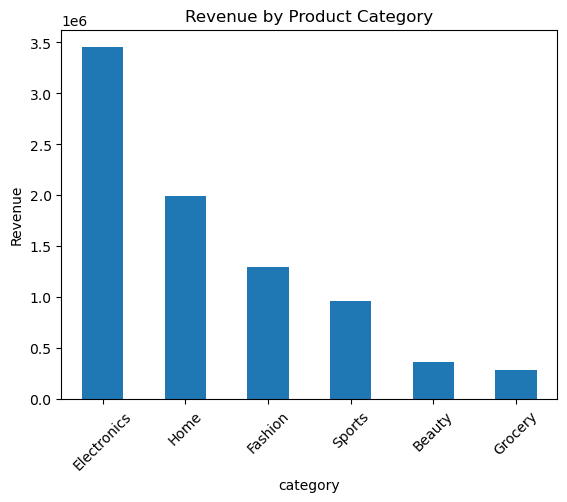

In [48]:
category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

## Revenue by Category Insights

Electronics is the dominant revenue-generating category, contributing substantially more revenue than all other product categories.

This may reflect:
- higher product pricing,
- stronger customer demand,
- or the contribution of premium products.

Home products also represent a significant revenue contributor, while Grocery and Beauty generate comparatively limited revenue.

Lower-performing categories may represent:
- underexploited opportunities,
- weaker conversion performance,
- or lower customer demand.

### Refund Rate by Product Category

In [49]:
refund_by_category = (
    transactions_products
    .groupby("category")["refund_flag"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

refund_by_category

category
Sports         3.235641
Beauty         3.100607
Electronics    2.967528
Grocery        2.882683
Fashion        2.792285
Home           2.752294
Name: refund_flag, dtype: float64

## Refund Rate by Category Insights

Refund rates remain relatively stable across product categories, ranging between approximately 2.7% and 3.2%.

Sports and Beauty categories show the highest refund rates, which may indicate:
- product expectation mismatches,
- sizing or quality issues,
- or weaker customer satisfaction.

Although Electronics does not have the highest refund percentage, it represents the most financially significant category due to its dominant revenue contribution.

As a result, even moderate refund activity within Electronics may have a meaningful impact on profitability and revenue retention.

---


# 10. Acquisition Channel Analysis

### Revenue by Acquisition Channel

In [50]:
channel_revenue = (
    transactions_customers
    .groupby("acquisition_channel")["gross_revenue"]
    .sum()
    .sort_values(ascending=False)
)

channel_revenue

acquisition_channel
Organic        2565334.77
Paid Search    2499671.93
Email          1255819.95
Social         1218334.54
Referral        834805.17
Name: gross_revenue, dtype: float64

## Revenue by Acquisition Channel Insights

Organic and Paid Search channels generate the highest revenue contribution, suggesting that search-driven acquisition plays a major role in overall business performance.

Strong Organic performance may indicate:
- effective SEO visibility,
- strong brand awareness,
- or high-intent customer traffic.

Paid Search also contributes significantly to revenue, suggesting that paid acquisition campaigns are effective at driving monetizable traffic.

Email marketing generates meaningful revenue as well, which may reflect successful retention and reactivation strategies targeting existing customers.

Referral remains the lowest-performing acquisition channel and may represent either:
- a lower strategic priority,
- or a potential underdeveloped growth opportunity.

## Average Revenue Per Customer by Acquisition Channel

In [51]:
revenue_per_customer = (
    transactions_customers
    .groupby("acquisition_channel")
    .agg(
        total_revenue=("gross_revenue", "sum"),
        unique_customers=("customer_id", "nunique")
    )
)

revenue_per_customer["revenue_per_customer"] = (
    revenue_per_customer["total_revenue"] /
    revenue_per_customer["unique_customers"]
)

revenue_per_customer.sort_values(
    by="revenue_per_customer",
    ascending=False
)

,total_revenue,unique_customers,revenue_per_customer
acquisition_channel,,,
Email,1255819.95,8899,141.119221
Organic,2565334.77,18210,140.875056
Referral,834805.17,5986,139.459601
Paid Search,2499671.93,18064,138.378650
Social,1218334.54,8932,136.401090


## Revenue per Customer Insights

While Organic traffic generates the highest total revenue, Email customers generate the highest revenue per customer.

This suggests that retention and CRM-driven acquisition strategies may produce particularly valuable customers with stronger purchasing behavior.

Organic traffic combines both:
- high total revenue,
- and strong customer value,

making it one of the most strategically important acquisition channels.

Social acquisition generates comparatively lower revenue per customer, which may indicate lower purchase intent or weaker conversion quality.

---

# 11. Loyalty Tier Analysis

### Revenue by Loyalty Tier

In [52]:
loyalty_revenue = (
    transactions_customers
    .groupby("loyalty_tier")
    .agg(
        total_revenue=("gross_revenue", "sum"),
        unique_customers=("customer_id", "nunique"),
        avg_order_value=("gross_revenue", "mean")
    )
    .sort_values(by="total_revenue", ascending=False)
)

loyalty_revenue

,total_revenue,unique_customers,avg_order_value
loyalty_tier,,,
Bronze,4477838.77,33862,90.193542
Silver,2302086.76,15860,91.599823
Gold,1275144.30,8262,89.133531
Platinum,318896.53,2107,88.754949


### Loyalty Tier Insights

Bronze customers generate the highest overall revenue contribution, primarily due to their large customer base.

However, Silver customers exhibit the highest Average Order Value, suggesting stronger purchasing behavior on a per-transaction basis.

Interestingly, Gold and Platinum customers do not demonstrate substantially higher order values compared to lower tiers. This may indicate:
- limited differentiation in customer spending behavior across loyalty levels,
- or opportunities to strengthen the effectiveness of the loyalty program.

The relatively small Platinum customer base may also suggest an opportunity to improve customer progression toward higher loyalty tiers.

### Average Order Value by Loyalty Tier

In [53]:
aov_loyalty = (
    transactions_customers
    .groupby("loyalty_tier")["gross_revenue"]
    .mean()
    .sort_values(ascending=False)
)

aov_loyalty

loyalty_tier
Silver      91.599823
Bronze      90.193542
Gold        89.133531
Platinum    88.754949
Name: gross_revenue, dtype: float64

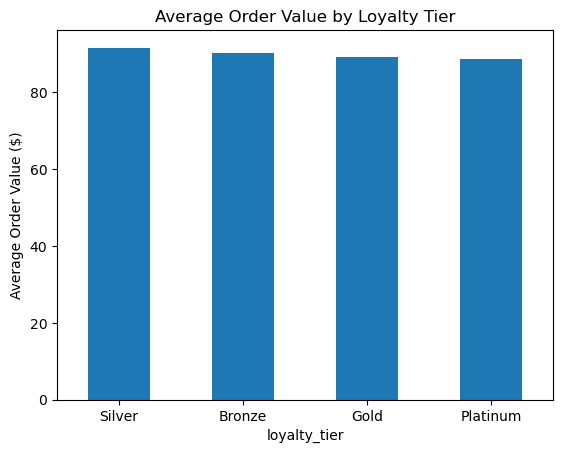

In [54]:
aov_loyalty.plot(kind="bar")

plt.title("Average Order Value by Loyalty Tier")

plt.ylabel("Average Order Value ($)")

plt.xticks(rotation=0)

plt.show()

### Average Order Value by Loyalty Tier Insights

Silver customers show the highest Average Order Value, meaning they spend slightly more per transaction compared to other loyalty tiers.

Gold and Platinum customers do not show significantly higher order values, but earlier analysis showed that they purchase more frequently.

This suggests that higher loyalty tiers may influence repeat purchasing behavior more than basket size.

### Transactions per Customer by Loyalty Tier

In [55]:
loyalty_frequency = (
    transactions_customers
    .groupby("loyalty_tier")
    .agg(
        transactions=("customer_id", "count"),
        unique_customers=("customer_id", "nunique")
    )
)

loyalty_frequency["transactions_per_customer"] = (
    loyalty_frequency["transactions"] /
    loyalty_frequency["unique_customers"]
)

loyalty_frequency.sort_values(
    by="transactions_per_customer",
    ascending=False
)

,transactions,unique_customers,transactions_per_customer
loyalty_tier,,,
Gold,14306,8262,1.731542
Platinum,3593,2107,1.705268
Silver,25132,15860,1.584615
Bronze,49647,33862,1.466157


## Loyalty Frequency Insights

Gold and Platinum customers demonstrate the highest transaction frequency per customer, suggesting that higher loyalty tiers are associated with stronger repeat purchasing behavior.

Interestingly, these higher-tier customers do not exhibit substantially higher Average Order Values compared to lower tiers. This suggests that the loyalty program may currently influence purchase frequency more effectively than basket size.

Bronze customers generate the largest overall revenue contribution due to their large population, but they show the lowest transaction frequency, indicating lower long-term engagement.

Silver customers represent an especially interesting segment because they combine:
- the highest Average Order Value,
- with moderate purchase frequency.

This may represent a strong opportunity for targeted retention and upsell strategies aimed at moving Silver customers toward higher loyalty engagement.

---

# 12. Conversion Funnel Analysis
where customers are lost before generating revenue.

### Counting each event type

In [56]:
event_counts = (
    events_df["event_type"]
    .value_counts()
)

event_counts

event_type
view           1043573
click           379008
add_to_cart     284370
bounce          189922
purchase        103127
Name: count, dtype: int64

### Calculating percentages

In [57]:
event_percentages = (
    events_df["event_type"]
    .value_counts(normalize=True) * 100
)

event_percentages

event_type
view           52.17865
click          18.95040
add_to_cart    14.21850
bounce          9.49610
purchase        5.15635
Name: proportion, dtype: float64

### Creating funnel visualization

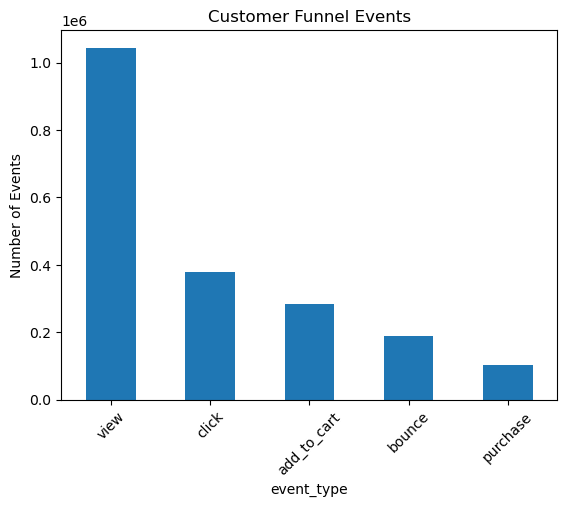

In [58]:
event_counts.plot(kind="bar")

plt.title("Customer Funnel Events")

plt.ylabel("Number of Events")

plt.xticks(rotation=45)

plt.show()

### Calculating Purchase Rate

In [59]:
purchase_rate = (
    (events_df["event_type"] == "purchase").mean() * 100
)

purchase_rate

5.15635

### Calculating Bounce Rate

In [60]:
bounce_rate = (
    (events_df["event_type"] == "bounce").mean() * 100
)

bounce_rate

9.4961

## Conversion Funnel Insights

The conversion funnel analysis highlights how users progress from website interaction to completed purchases.

The purchase rate is approximately 5.16%, meaning that only a relatively small proportion of user events ultimately result in a purchase. This is expected in e-commerce environments where many users browse products without completing transactions.

The bounce rate is approximately 9.50%, indicating that a noticeable proportion of users leave the platform quickly without meaningful interaction. This may suggest:
- low-intent traffic,
- weak landing page engagement,
- or early-stage user friction.

The gap between browsing activity and completed purchases suggests potential conversion drop-off during the customer journey. Possible explanations may include:
- checkout friction,
- pricing sensitivity,
- shipping costs,
- payment issues,
- or product decision hesitation.

Improving conversion efficiency within the funnel could represent an important opportunity for increasing revenue without necessarily increasing traffic acquisition costs.

---

# 13. Device Conversion Analysis

### Analysing event distribution by device

In [61]:
device_events = pd.crosstab(
    events_df["device_type"],
    events_df["event_type"]
)

device_events

event_type,add_to_cart,bounce,click,purchase,view
device_type,,,,,
Unknown,5832,3813,7624,2076,20955
desktop,97487,65284,129562,35323,357777
mobile,167285,111480,222896,60657,613828
tablet,13766,9345,18926,5071,51013


### Calculating purchase rate by device

In [62]:
purchase_by_device = (
    events_df
    .groupby("device_type")
    .apply(
        lambda x: (x["event_type"] == "purchase").mean() * 100
    )
    .sort_values(ascending=False)
)

purchase_by_device

C:\Users\Tooba Shaukat\AppData\Local\Temp\ipykernel_1324\398380879.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


device_type
tablet     5.168109
mobile     5.157268
desktop    5.153385
Unknown    5.151365
dtype: float64

### Calculating bounce rate by device

In [63]:
bounce_by_device = (
    events_df
    .groupby("device_type")
    .apply(
        lambda x: (x["event_type"] == "bounce").mean() * 100
    )
    .sort_values(ascending=False)
)

bounce_by_device

C:\Users\Tooba Shaukat\AppData\Local\Temp\ipykernel_1324\962883107.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


device_type
desktop    9.524490
tablet     9.523955
mobile     9.478415
Unknown    9.461538
dtype: float64

### Visualising purchase rate by device

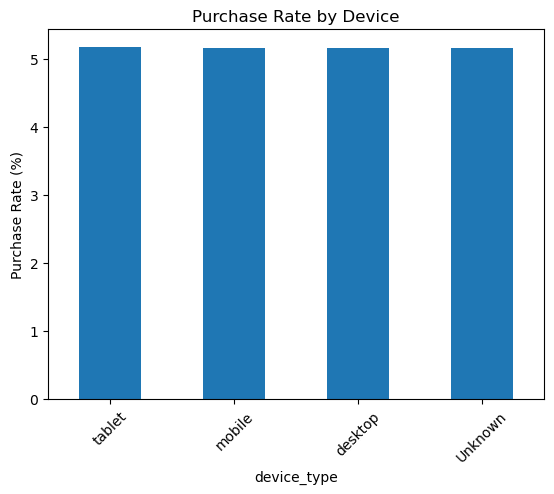

In [64]:
purchase_by_device.plot(kind="bar")

plt.title("Purchase Rate by Device")

plt.ylabel("Purchase Rate (%)")

plt.xticks(rotation=45)

plt.show()

## Device Conversion Insights

Despite mobile representing the majority of platform traffic, conversion rates remain remarkably consistent across all device types.

Purchase rates are nearly identical between:
- mobile,
- desktop,
- and tablet users.

Bounce rates also remain highly stable across devices, suggesting that the platform currently provides a relatively consistent user experience regardless of device type.

This indicates that device-specific friction does not appear to be a major conversion issue at a high level.

---

# 14. Traffic Source Conversion Analysis

### Purchase rate by traffic source

In [65]:
purchase_by_source = (
    events_df
    .groupby("traffic_source")["event_type"]
    .apply(lambda x: (x == "purchase").mean() * 100)
    .sort_values(ascending=False)
)

purchase_by_source

traffic_source
Email          8.889334
Paid Search    8.411657
Social         7.294411
Direct         2.102502
Organic        2.093096
Name: event_type, dtype: float64

### Bounce rate by traffic source

In [66]:
bounce_by_source = (
    events_df
    .groupby("traffic_source")["event_type"]
    .apply(lambda x: (x == "bounce").mean() * 100)
    .sort_values(ascending=False)
)

bounce_by_source

traffic_source
Organic        9.833364
Direct         9.745097
Social         9.249644
Paid Search    9.182469
Email          9.094580
Name: event_type, dtype: float64

### Visualising purchase rate

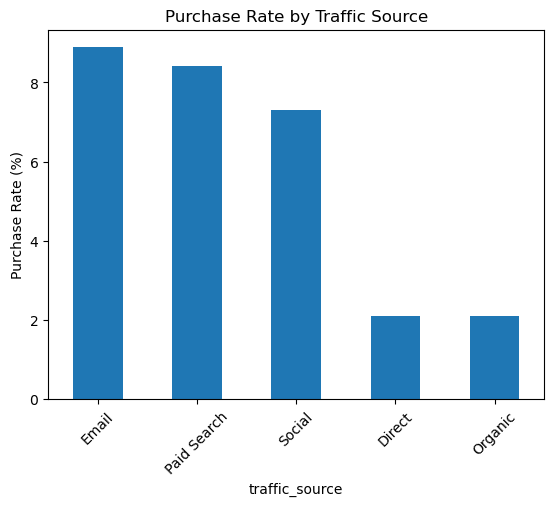

In [67]:
purchase_by_source.plot(kind="bar")

plt.title("Purchase Rate by Traffic Source")

plt.ylabel("Purchase Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Visualising bounce rate

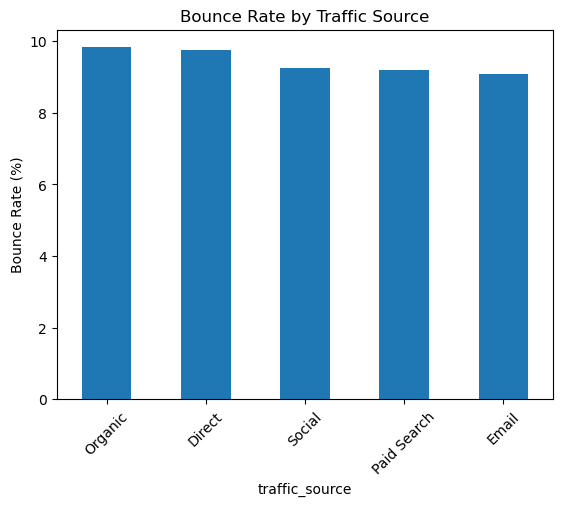

In [68]:
bounce_by_source.plot(kind="bar")

plt.title("Bounce Rate by Traffic Source")

plt.ylabel("Bounce Rate (%)")

plt.xticks(rotation=45)

plt.show()

## Traffic Source Conversion Insights

Email traffic demonstrates the highest purchase conversion rate, suggesting that CRM and retention-driven traffic sources generate highly engaged and high-intent users.

Paid Search also performs strongly, indicating effective acquisition targeting and strong commercial intent among paid users.

Organic traffic generates substantial overall revenue but exhibits comparatively low purchase conversion rates. This suggests that Organic channels may attract broader exploratory traffic with lower immediate purchase intent.

Bounce rates remain relatively stable across traffic sources, although Organic and Direct traffic show slightly higher bounce behavior compared to Email and Paid Search.

Overall, the analysis suggests that:
- Email and Paid Search deliver the strongest conversion efficiency,
- while Organic traffic plays a major role in top-of-funnel acquisition and long-term traffic generation.

---

# 15. A/B Testing Analysis

### Counting events by experiment group

In [69]:
experiment_counts = pd.crosstab(
    events_df["experiment_group"],
    events_df["event_type"]
)

experiment_counts

event_type,add_to_cart,bounce,click,purchase,view
experiment_group,,,,,
Control,170912,114579,227428,56855,628630
Variant_A,57100,38150,76463,21045,208655
Variant_B,56358,37193,75117,25227,206288


### Purchase rate by experiment group

In [70]:
purchase_by_experiment = (
    events_df
    .groupby("experiment_group")["event_type"]
    .apply(lambda x: (x == "purchase").mean() * 100)
    .sort_values(ascending=False)
)

purchase_by_experiment

experiment_group
Variant_B    6.303866
Variant_A    5.242730
Control      4.744226
Name: event_type, dtype: float64

### Bounce rate by experiment group

In [71]:
bounce_by_experiment = (
    events_df
    .groupby("experiment_group")["event_type"]
    .apply(lambda x: (x == "bounce").mean() * 100)
    .sort_values(ascending=False)
)

bounce_by_experiment

experiment_group
Control      9.560966
Variant_A    9.503927
Variant_B    9.293998
Name: event_type, dtype: float64

### Session duration by experiment group

In [72]:
session_duration_experiment = (
    events_df
    .groupby("experiment_group")["session_duration_sec"]
    .mean()
    .sort_values(ascending=False)
)

session_duration_experiment

experiment_group
Control      130.751562
Variant_A    130.561575
Variant_B    130.397658
Name: session_duration_sec, dtype: float64

### Visualising purchase rate

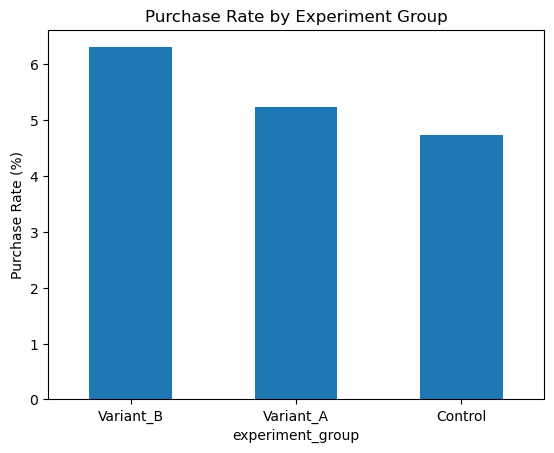

In [73]:
purchase_by_experiment.plot(kind="bar")

plt.title("Purchase Rate by Experiment Group")

plt.ylabel("Purchase Rate (%)")

plt.xticks(rotation=0)

plt.show()

## A/B Testing Insights

Variant_B demonstrates the strongest overall performance across the experiment groups.

Compared to the Control group:
- Variant_B achieves the highest purchase conversion rate,
- while also slightly reducing bounce rate.

This suggests that Variant_B may provide a more effective or less frictional user experience during the customer journey.

Session duration remains relatively stable across all experiment groups, indicating that the improvement in conversion performance is not driven by longer browsing sessions but potentially by more efficient user interaction or improved purchase flow.

Overall, Variant_B appears to be the most effective experiment variation and may represent the strongest candidate for broader deployment.

---

# 16. Session Duration & Purchase Behavior Analysis

Do purchasing users behave differently from bouncing users?

### Average session duration by event type

In [74]:
session_by_event = (
    events_df
    .groupby("event_type")["session_duration_sec"]
    .mean()
    .sort_values(ascending=False)
)

session_by_event

event_type
view           130.831896
bounce         130.799660
click          130.519052
add_to_cart    130.438482
purchase       129.455054
Name: session_duration_sec, dtype: float64

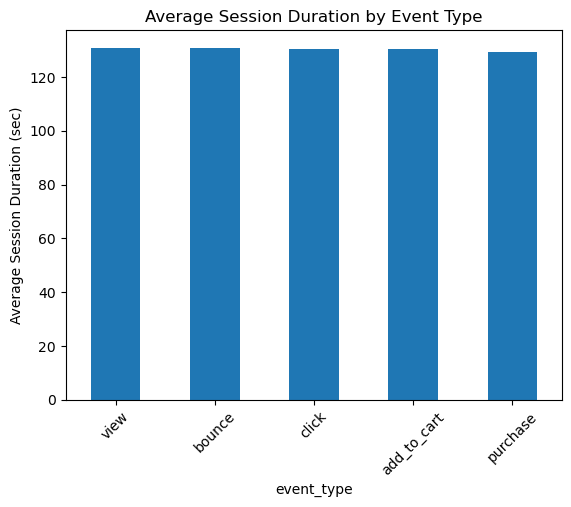

In [75]:
session_by_event.plot(kind="bar")

plt.title("Average Session Duration by Event Type")

plt.ylabel("Average Session Duration (sec)")

plt.xticks(rotation=45)

plt.show()

## Session Duration Insights

Average session duration remains relatively stable across all event types, with only minor differences between purchasing, browsing, and bounce behavior.

This suggests that session duration alone may not strongly explain conversion behavior within the platform.

Purchasing users do not appear to spend substantially more time on the platform than non-purchasing users, which may indicate:
- relatively fast purchase decision-making,
- efficient navigation behavior,
- or the influence of other conversion drivers such as traffic quality, pricing, or user intent.

---

# 17. Final Insights And Recommendations

## Key Findings

- Electronics is the strongest revenue-generating category.
- Email traffic shows the highest purchase conversion rate.
- Organic traffic generates high revenue but lower conversion efficiency.
- Gold and Platinum customers purchase more frequently.
- Variant_B achieved the strongest conversion performance.
- Around 10% of transactions appear incomplete and may indicate tracking or checkout issues.

---

## Business Recommendations



## 1. Strengthen Email and Paid Search strategies

Email shows the highest purchase conversion rate, while Paid Search also performs strongly.  
These channels appear to bring high-intent users and should be prioritized for conversion-focused campaigns.

## 2. Maintain Organic as a key acquisition channel

Organic generates strong revenue volume, but its purchase conversion rate is lower than Email and Paid Search.  
This suggests that Organic is valuable for traffic generation and brand visibility, but visitors may need better nurturing before purchase.

## 3. Scale Variant_B experience

Variant_B achieved the highest purchase rate and the lowest bounce rate among experiment groups.  
This version appears to improve conversion efficiency and should be considered for broader deployment.

## 4. Improve tracking of incomplete transactions

Around 10% of transactions contain missing product and revenue information.  
This may indicate failed transactions, incomplete checkout tracking, or revenue attribution issues.

This should be investigated because it can affect:
- revenue reporting,
- campaign performance analysis,
- and product-level profitability analysis.

## 5. Optimize loyalty progression

Gold and Platinum customers purchase more frequently, while Silver customers show the highest average order value.  
A strong opportunity would be to encourage Silver customers to become more engaged and move toward higher loyalty tiers.

## 6. Monitor category-level performance

Electronics is the strongest revenue-driving category, while Sports and Beauty show the highest refund rates.  
Although refund rates are not alarming, high-revenue categories like Electronics should be monitored closely because even moderate refunds can have a larger financial impact.

---
    
## Priority KPIs to monitor weekly

- Total revenue
- Average Order Value
- Purchase conversion rate
- Bounce rate
- Refund rate
- Revenue by acquisition channel
- Revenue by product category
- Revenue per customer
- Transactions per customer
- Incomplete transaction rate

---

## Potential Next Steps

- Build a real-time dashboard for KPI monitoring.
- Further investigate incomplete transactions.
- Analyze customer retention over time.
- Explore campaign ROI if marketing spend data becomes available.

---

## Exporting Clean Datasets

In [76]:
transactions_products.to_csv(
    "transactions_products.csv",
    index=False
)

transactions_customers.to_csv(
    "transactions_customers.csv",
    index=False
)

## Creating a reduced events dataset for looker studio

In [77]:
events_dashboard = events_df[[
    "event_type",
    "device_type",
    "traffic_source",
    "experiment_group",
    "session_duration_sec"
]]

In [78]:
events_dashboard.to_csv(
    "events_dashboard.csv",
    index=False
)

---